# Tutorial 01 — Getting started with Py3D

This notebook walks through the simplest possible Py3D session:

1. Open a `Movie` pointing at the example simulation.
2. Read one timestep of the magnetic field.
3. Plot it with `py3d.ims`, with magnetic-flux contours overlaid.

If you have not set up the conda environment yet, see [SETUP.md](../SETUP.md).

## Imports

`py3d` is the library; `data_path` is a tiny module in the `tutorials/` directory that holds the path to the example dataset (so you can override it once via the `PY3D_TUTORIAL_DATA` env var instead of editing every notebook).

In [1]:
import sys
import os

# Make the tutorials/ directory importable so we can pull in data_path.
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import py3d
from py3d.sub import calc_psi
from data_path import DATA_DIR, PARAM_FILE, NAME_STYLE, require_data_dir

require_data_dir()
print('DATA_DIR =', DATA_DIR)

DATA_DIR = /Users/colby/Research/Programing/P3D_example_simulation_data/staging


## Open the movie

`Movie` is the top-level class for time-series field output. Three things to know:

- **`num=0`** picks the movie file number. The example run has only `num=0`.
- **`name_style='p3d'`** is the default — the example uses `movie.bx.000` style filenames.
- **`interactive=False`** makes Py3D raise immediately on missing files, instead of prompting on stdin. In a Jupyter session you can drop this and the default `interactive=True` will prompt for any path it cannot find.

In [2]:
m = py3d.Movie(
    num=0,
    path=DATA_DIR,
    param_file=PARAM_FILE,
    name_style=NAME_STYLE,
    interactive=False,
)

print(f'Frames available: {m.ntimes}')
print(f'Domain:           lx = {m.param["lx"]}, ly = {m.param["ly"]}')

Frames available: 51
Domain:           lx = 51.2, ly = 25.6


## Read fields at one timestep

`get_fields(varnames, time=t)` returns a dict of NumPy arrays plus the spatial axes (`xx`, `yy`) and metadata. Variable names are passed as a single space-separated string. We grab `bx`, `by`, `bz` together — `bx` and `by` are needed by `calc_psi` later for the flux contours.

In [3]:
time_index = m.ntimes // 2     # midway through the run
d = m.get_fields('bx by bz', time=time_index)

print(f'Field shape: bz = {d["bz"].shape}')
print(f'             xx = {d["xx"].shape}, yy = {d["yy"].shape}')
print(f'Time:        {d["tt"][-1]:.2f} (in units of 1/Omega_ci)')

Field shape: bz = (1024, 512)
             xx = (1024,), yy = (512,)
Time:        24.00 (in units of 1/Omega_ci)


## Axis convention — the most important gotcha

**The first axis of every field array is x, the second is y.** So `d['bz'][i, j]` is Bz at `x = d['xx'][i]`, `y = d['yy'][j]`.

This is the opposite of the row-major convention `imshow` expects, so do **not** call `imshow(d['bz'])` directly — it will be transposed. Use `py3d.ims`, which handles the transpose, sets extents from `xx`/`yy`, and can overlay magnetic-flux contours for you.

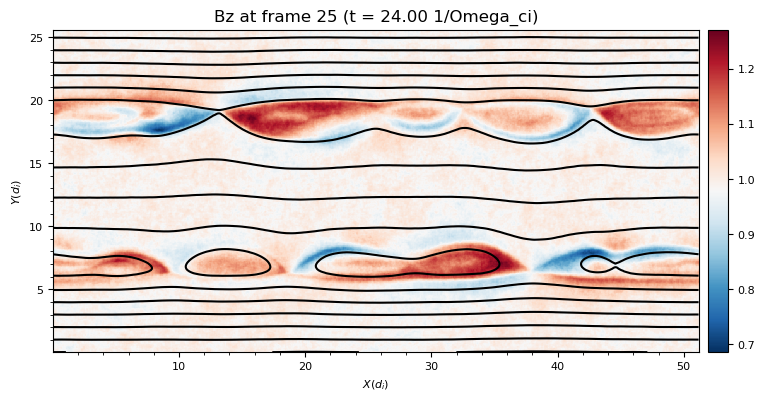

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
py3d.ims(d, 'bz', ax=ax, cbar=True, cont=True, cmap='RdBu_r')
ax.set_title(f'Bz at frame {time_index} (t = {d["tt"][-1]:.2f} 1/Omega_ci)')
fig.tight_layout()

The black contours are level sets of the magnetic-flux function ψ. In a 2D simulation, ψ contours are field lines of the in-plane magnetic field. Reconnection shows up as the topology of these lines changing — closed islands forming and growing along the current sheet.

## A first reconnection diagnostic

`calc_psi(d)` returns ψ as a 2D array. The peak-to-peak excursion of ψ is a quick proxy for how much magnetic flux has been reconnected by this frame. We will plot it vs. time in tutorial 03.

In [5]:
psi = calc_psi(d)
print(f'psi range at frame {time_index}: '
      f'[{psi.min():+.4f}, {psi.max():+.4f}], '
      f'span = {psi.max() - psi.min():.4f}')

psi range at frame 25: [-7.6878, +0.0568], span = 7.7446


## What you just learned

- `py3d.Movie(num=, path=, param_file=, name_style=, interactive=False)` — open a simulation.
- `m.get_fields('bx by bz', time=t)` — read fields at one timestep, returns a dict.
- `py3d.ims(d, 'bz', cbar=True, cont=True)` — plot a field with the right transpose, extents, and ψ contours.
- `py3d.sub.calc_psi(d)` — compute the magnetic-flux function from `bx`/`by`.

**Next:** [Tutorial 02 — Exploring fields](02_exploring_fields.ipynb) loads all 30 movie variables at once and builds a multi-panel plot.